# Equatorial Pacific Potential Temperature — CESM2-LE

Reads CESM2-LE POP ocean TEMP files (monthly, 1850–2014), averages over 5°S–5°N,
and produces three plots:
1. **Climatological section** — depth × longitude for a chosen month/season
2. **Anomaly section** — depth × longitude anomaly for a chosen period & season
3. **Time–longitude Hovmöller** — TEMP anomaly at a fixed depth

In [60]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

## Configuration

In [61]:
# --- Model case ---
case_stub = 'b.e21.BHISTcmip6.f09_g17.LE2-1001.001'
data_dir  = '/glade/campaign/collections/gdex/data/d651056/CESM2-LE/ocn/proc/tseries/month_1/TEMP/'

# --- Season / month selection ---
# A list of month ints, or a single int.  Examples:
#   [12, 1, 2]  → DJF      [3, 4, 5]   → MAM
#   [6, 7, 8]   → JJA      [9,10,11]   → SON
#   [3]         → March only
month_sel    = [2]   # DJF
#month_sel    = [9, 10, 11]   # DJF
season_label = 'FEB'

# --- Climatology period (used as the base for anomalies) ---
clim_yr0, clim_yr1 = 1960, 2014

# --- Period for the anomaly section plot (Plot 2) ---
anom_yr0, anom_yr1 = 1979, 1980   # e.g. the 1997-98 El Niño

# --- Fixed depth for the Hovmöller (Plot 3), in metres ---
hov_depth_m = 100.

# --- Domain ---
lat_s, lat_n  = -5.,  5.     # equatorial band
lon_w, lon_e  = 120., 290.   # Pacific window (°E, 0–360)
z_max_m       = 400.         # max depth to plot (m)

# --- Output ---
dir_fig = '/glade/work/rneale/git/python-scripts/NESSI/sheen'

## Helper functions

In [62]:
def season_mean(da, months):
    """Return time-mean of da for the given list of months."""
    mask = da.time.dt.month.isin(months)
    return da.sel(time=mask).mean('time')


def season_select(da, months):
    """Return da subset to the given months."""
    return da.sel(time=da.time.dt.month.isin(months))


def lon_label(lon):
    """Format a 0–360 longitude as E/W string."""
    if lon > 180:
        return f'{360 - lon:.0f}°W'
    return f'{lon:.0f}°E'


def add_lon_ticks(ax, lons, step=20):
    """Add nicely labelled longitude ticks to an axis."""
    ticks = np.arange(np.ceil(lons.min() / step) * step,
                      lons.max() + step, step)
    ax.set_xticks(ticks)
    ax.set_xticklabels([lon_label(t) for t in ticks], fontsize=9)

## Load TEMP files and open with dask

In [63]:
files = sorted(glob.glob(data_dir + case_stub + '.pop.h.TEMP.*.nc'))
print(f'Files found: {len(files)}')
for f in files:
    print(' ', f.split('/')[-1])

Files found: 17
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.185001-185912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.186001-186912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.187001-187912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.188001-188912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.189001-189912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.190001-190912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.191001-191912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.192001-192912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.193001-193912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.194001-194912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.195001-195912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.196001-196912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.197001-197912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1001.001.pop.h.TEMP.198001-198912.nc
  b.e21.BHISTcmip6.f09_g17.LE2-1

In [64]:
ds = xr.open_mfdataset(
    files,
    combine='by_coords',
    data_vars=['TEMP'],
    coords='minimal',
    compat='override',
    parallel=True,
    decode_timedelta=False,
)

# Depth in metres (z_t is stored in cm)
z_m = ds['z_t'].values / 100.

print(ds['TEMP'])
print(f'\nTime range : {str(ds.time.values[0])[:7]} – {str(ds.time.values[-1])[:7]}')
print(f'Depth range: {z_m[0]:.0f} – {z_m[-1]:.0f} m  ({len(z_m)} levels)')

<xarray.DataArray 'TEMP' (time: 1980, z_t: 60, nlat: 384, nlon: 320)> Size: 58GB
dask.array<concatenate, shape=(1980, 60, 384, 320), dtype=float32, chunksize=(1, 30, 192, 160), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-02-01 00:00:00 ... 2015-01-01 00:00:00
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
    ULONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    ULAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLONG    (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
    TLAT     (nlat, nlon) float64 983kB dask.array<chunksize=(384, 320), meta=np.ndarray>
Dimensions without coordinates: nlat, nlon
Attributes:
    long_name:     Potential Temperature
    units:         degC
    grid_loc:      3111
    cell_methods:  time: mean

Time range : 1850-02 – 2015-01
Depth range: 5 – 5375 m  (60 levels)


## Extract equatorial band (5°S–5°N) — latitude-weighted average

POP uses a displaced-pole (bipolar) grid; TLAT/TLONG are 2-D.  
We build a latitude-weighted mask over the 5°S–5°N band and collapse the `nlat`
dimension.  The resulting `nlon` dimension maps cleanly onto the mean equatorial
TLONG values, which increase monotonically across the basin.

In [65]:
tlat  = ds['TLAT']   # (nlat, nlon)
tlong = ds['TLONG']  # (nlat, nlon)

# Mask and cosine weights for equatorial band
eq_mask     = (tlat >= lat_s) & (tlat <= lat_n)
weights_2d  = np.cos(np.deg2rad(tlat)).where(eq_mask)

# Lat-weighted meridional average → (time, z_t, nlon)
temp    = ds['TEMP']
temp_eq = (temp * weights_2d).sum('nlat') / weights_2d.sum('nlat')

# Representative longitude for each nlon column (mean over equatorial rows)
tlong_eq = tlong.where(eq_mask).mean('nlat').compute()  # (nlon,)

print(f'Equatorial nlat rows used: {int(eq_mask.any("nlon").sum().values)}')
print(f'TLONG range: {float(tlong_eq.min()):.1f} – {float(tlong_eq.max()):.1f} °E')

Equatorial nlat rows used: 38
TLONG range: 1.1 – 359.9 °E


## Subset to Pacific and assign regular longitude coordinate

In [66]:
# Boolean index for Pacific columns
pac_idx = ((tlong_eq >= lon_w) & (tlong_eq <= lon_e)).values

temp_pac  = temp_eq.isel(nlon=pac_idx)                   # (time, z_t, nlon_pac)
lon_pac   = tlong_eq.values[pac_idx]                     # 1-D longitude array

# Replace the integer nlon index with actual longitude values
temp_pac  = temp_pac.assign_coords(nlon=lon_pac).rename({'nlon': 'lon'})

# Depth index for plotting (keep only z_max_m and above)
z_idx = z_m <= z_max_m

print(f'Pacific columns : {len(lon_pac)}')
print(f'Lon range       : {lon_pac[0]:.1f} – {lon_pac[-1]:.1f} °E')
print(f'Depth levels    : {z_idx.sum()} (0 – {z_m[z_idx][-1]:.0f} m)')
print('temp_pac:', temp_pac)

Pacific columns : 151
Lon range       : 120.3 – 289.1 °E
Depth levels    : 30 (0 – 378 m)
temp_pac: <xarray.DataArray (time: 1980, z_t: 60, lon: 151)> Size: 144MB
dask.array<getitem, shape=(1980, 60, 151), dtype=float64, chunksize=(1, 30, 151), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 16kB 1850-02-01 00:00:00 ... 2015-01-01 00:00:00
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
  * lon      (lon) float64 1kB 120.3 121.4 122.6 123.7 ... 286.8 287.9 289.1
Attributes:
    grid_loc:      3111
    cell_methods:  time: mean
    long_name:     array of t-grid latitudes
    units:         degrees_north


## Compute climatology and anomalies

In [67]:
# Monthly climatology over clim_yr0–clim_yr1
clim_mask = (temp_pac.time.dt.year >= clim_yr0) & (temp_pac.time.dt.year <= clim_yr1)
clim      = temp_pac.sel(time=clim_mask).groupby('time.month').mean('time')  # (month, z_t, lon)

# Anomaly (lazy)
anom = temp_pac.groupby('time.month') - clim  # (time, z_t, lon)

print('Climatology computed (lazy).')
print(clim)

Climatology computed (lazy).
<xarray.DataArray (month: 12, z_t: 60, lon: 151)> Size: 870kB
dask.array<transpose, shape=(12, 60, 151), dtype=float64, chunksize=(1, 30, 151), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * z_t      (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
  * lon      (lon) float64 1kB 120.3 121.4 122.6 123.7 ... 286.8 287.9 289.1
Attributes:
    grid_loc:      3111
    cell_methods:  time: mean
    long_name:     array of t-grid latitudes
    units:         degrees_north


## Plot 1 — Climatological temperature section (depth × longitude)

Seasonal mean over the full record for the selected month(s).

Computing climatological section for FEB ...
Done.
Saved: /glade/work/rneale/git/python-scripts/NESSI/sheen/b.e21.BHISTcmip6.f09_g17.LE2-1001.001_ocn_TEMP_clim_FEB.png


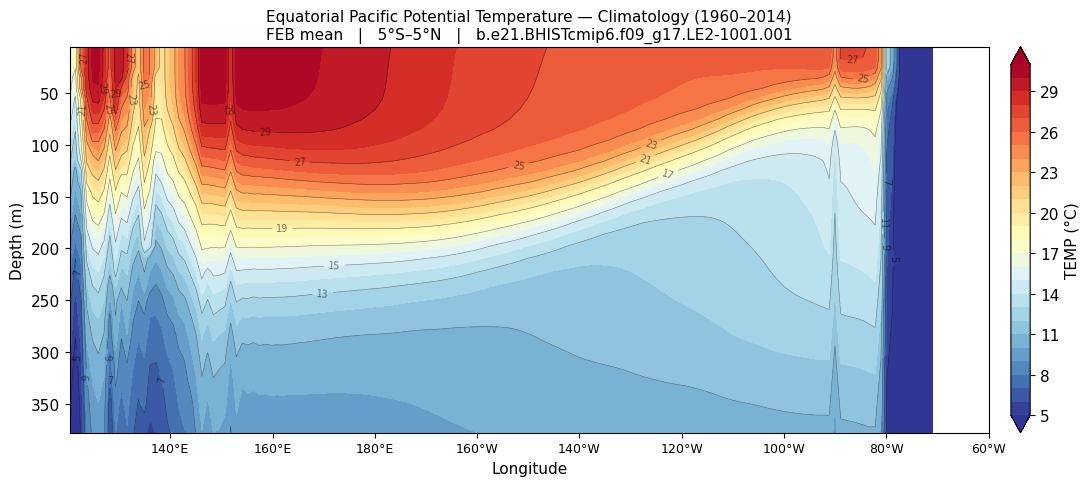

In [68]:
print(f'Computing climatological section for {season_label} ...')

# Seasonal climatology: mean over all years of the chosen months
clim_seas = season_mean(temp_pac.sel(time=clim_mask), month_sel).compute()
# Slice to z_max
clim_plot = clim_seas.isel(z_t=z_idx)

print('Done.')

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 5))
plt.rcParams.update({'font.size': 11})

levels_t = np.arange(5, 32, 1)
cf = ax.contourf(lon_pac, z_m[z_idx], clim_plot.values,
                 levels=levels_t, cmap='RdYlBu_r', extend='both')
cs = ax.contour(lon_pac, z_m[z_idx], clim_plot.values,
                levels=levels_t[::2], colors='k', linewidths=0.4, alpha=0.5)
ax.clabel(cs, fmt='%d', fontsize=7)

ax.invert_yaxis()
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Longitude')
add_lon_ticks(ax, lon_pac)
ax.set_title(
    f'Equatorial Pacific Potential Temperature — Climatology ({clim_yr0}–{clim_yr1})\n'
    f'{season_label} mean   |   5°S–5°N   |   {case_stub}',
    fontsize=11
)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, label='TEMP (°C)')
plt.tight_layout()

fname1 = f'{dir_fig}/{case_stub}_ocn_TEMP_clim_{season_label}.png'
fig.savefig(fname1, dpi=150, bbox_inches='tight')
print(f'Saved: {fname1}')
plt.show()

## Plot 2 — Temperature anomaly section for a chosen period & season

Mean anomaly over `anom_yr0`–`anom_yr1` for the selected month(s).

Computing anomaly section for FEB  1979–1980 ...
Done.
Saved: /glade/work/rneale/git/python-scripts/NESSI/sheen/b.e21.BHISTcmip6.f09_g17.LE2-1001.001_ocn_TEMP_anom_FEB_1979-1980.png


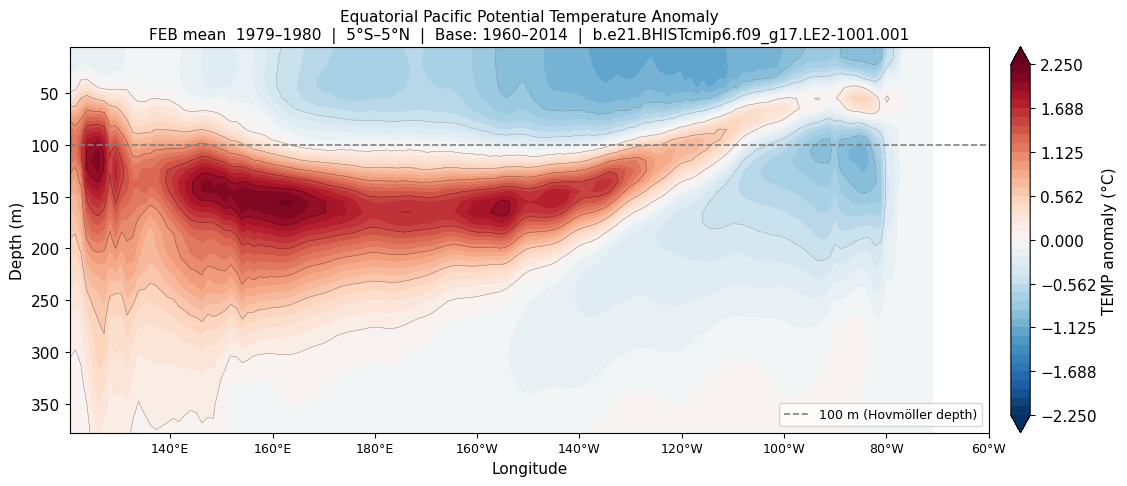

In [69]:
print(f'Computing anomaly section for {season_label}  {anom_yr0}–{anom_yr1} ...')

yr_mask  = (anom.time.dt.year >= anom_yr0) & (anom.time.dt.year <= anom_yr1)
anom_plot = season_mean(anom.sel(time=yr_mask), month_sel).isel(z_t=z_idx).compute()

print('Done.')

# Symmetric colour scale
vmax = float(np.abs(anom_plot).max())
vmax = np.ceil(vmax * 4) / 4   # round up to nearest 0.25
levels_a = np.linspace(-vmax, vmax, 41)

fig, ax = plt.subplots(figsize=(12, 5))
plt.rcParams.update({'font.size': 11})

cf = ax.contourf(lon_pac, z_m[z_idx], anom_plot.values,
                 levels=levels_a, cmap='RdBu_r', extend='both')
cs = ax.contour(lon_pac, z_m[z_idx], anom_plot.values,
                levels=[lv for lv in levels_a if lv != 0][::4],
                colors='k', linewidths=0.3, alpha=0.5)
ax.axhline(hov_depth_m, color='grey', lw=1.2, ls='--', label=f'{hov_depth_m:.0f} m (Hovmöller depth)')

ax.invert_yaxis()
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Longitude')
add_lon_ticks(ax, lon_pac)
ax.legend(fontsize=9, loc='lower right')
ax.set_title(
    f'Equatorial Pacific Potential Temperature Anomaly\n'
    f'{season_label} mean  {anom_yr0}–{anom_yr1}  |  5°S–5°N  |  '
    f'Base: {clim_yr0}–{clim_yr1}  |  {case_stub}',
    fontsize=11
)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, label='TEMP anomaly (°C)',
                    ticks=np.linspace(-vmax, vmax, 9))
plt.tight_layout()

fname2 = f'{dir_fig}/{case_stub}_ocn_TEMP_anom_{season_label}_{anom_yr0}-{anom_yr1}.png'
fig.savefig(fname2, dpi=150, bbox_inches='tight')
print(f'Saved: {fname2}')
plt.show()

## Plot 3 — Time–longitude Hovmöller at fixed depth

Monthly anomaly at `hov_depth_m` m for the chosen season, full 1850–2014 record.

Computing Hovmöller at 100 m, FEB ...
  Using z_t index 9 → 95 m
Done.
Saved: /glade/work/rneale/git/python-scripts/NESSI/sheen/b.e21.BHISTcmip6.f09_g17.LE2-1001.001_ocn_TEMP_hov_95m_FEB.png


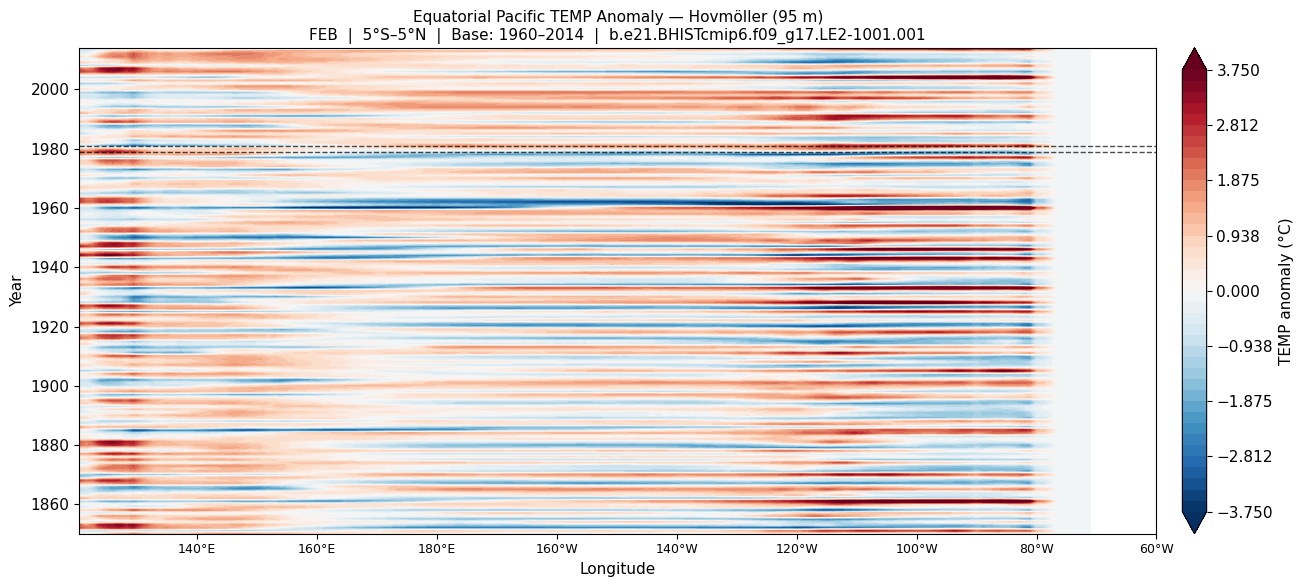

In [70]:
print(f'Computing Hovmöller at {hov_depth_m:.0f} m, {season_label} ...')

# Find the z_t index closest to hov_depth_m
z_idx_hov = int(np.argmin(np.abs(z_m - hov_depth_m)))
print(f'  Using z_t index {z_idx_hov} → {z_m[z_idx_hov]:.0f} m')

# Select depth, then pick seasonal months
anom_hov_all = season_select(anom.isel(z_t=z_idx_hov), month_sel).compute()
# anom_hov_all: (time_seas, lon)

# Build a decimal-year axis
yr_dec = anom_hov_all.time.dt.year.values + (anom_hov_all.time.dt.month.values - 1) / 12.

print('Done.')

# Symmetric colour scale
vmax_h = float(np.abs(anom_hov_all).quantile(0.98))
vmax_h = np.ceil(vmax_h * 4) / 4
levels_h = np.linspace(-vmax_h, vmax_h, 41)

fig, ax = plt.subplots(figsize=(14, 6))
plt.rcParams.update({'font.size': 11})

cf = ax.contourf(lon_pac, yr_dec, anom_hov_all.values,
                 levels=levels_h, cmap='RdBu_r', extend='both')

# Mark the anomaly period used in Plot 2
ax.axhline(anom_yr0, color='k', lw=1.0, ls='--', alpha=0.7)
ax.axhline(anom_yr1 + 1, color='k', lw=1.0, ls='--', alpha=0.7)

ax.set_ylabel('Year')
ax.set_xlabel('Longitude')
add_lon_ticks(ax, lon_pac)
ax.set_ylim(yr_dec[0], yr_dec[-1])
ax.set_title(
    f'Equatorial Pacific TEMP Anomaly — Hovmöller ({z_m[z_idx_hov]:.0f} m)\n'
    f'{season_label}  |  5°S–5°N  |  Base: {clim_yr0}–{clim_yr1}  |  {case_stub}',
    fontsize=11
)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, label='TEMP anomaly (°C)',
                    ticks=np.linspace(-vmax_h, vmax_h, 9))
plt.tight_layout()

fname3 = f'{dir_fig}/{case_stub}_ocn_TEMP_hov_{z_m[z_idx_hov]:.0f}m_{season_label}.png'
fig.savefig(fname3, dpi=150, bbox_inches='tight')
print(f'Saved: {fname3}')
plt.show()

## Bonus — Time–depth Hovmöller at a fixed longitude

Optionally visualise subsurface variability at a single longitude column.

Computing time–depth Hovmöller at 120°W (240.0°E), FEB ...
  Using lon index 106 → 239.56°E
Done.
Saved: /glade/work/rneale/git/python-scripts/NESSI/sheen/b.e21.BHISTcmip6.f09_g17.LE2-1001.001_ocn_TEMP_tdepth_240E_FEB.png


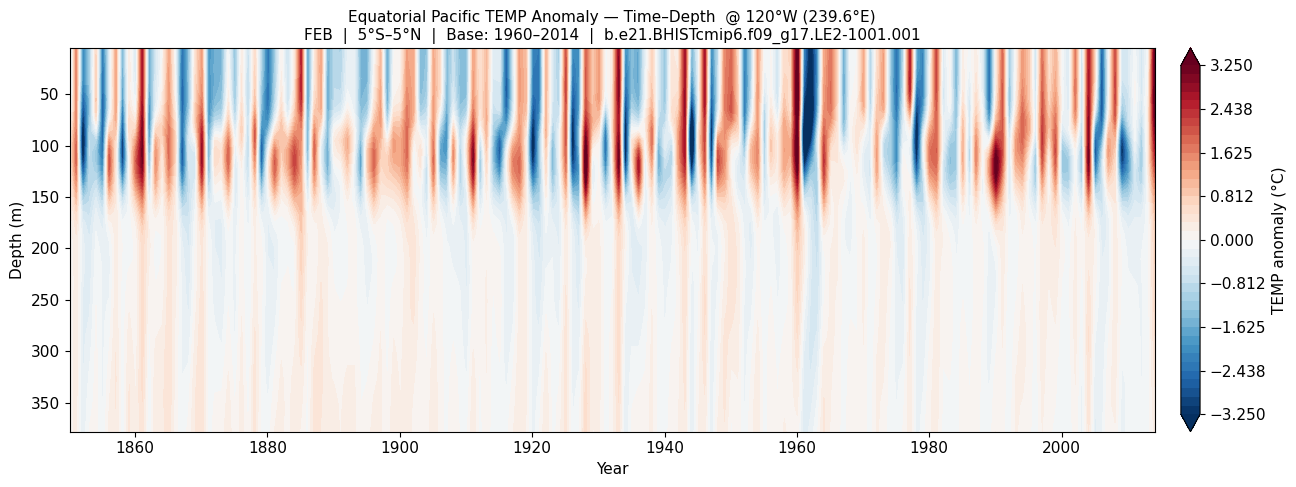

In [71]:
# Pick a longitude (°E, 0–360) — e.g. 240°E = 120°W (Niño-3 region)
hov_lon = 240.

print(f'Computing time–depth Hovmöller at {lon_label(hov_lon)} ({hov_lon}°E), {season_label} ...')

# Nearest longitude column
lon_idx = int(np.argmin(np.abs(lon_pac - hov_lon)))
print(f'  Using lon index {lon_idx} → {lon_pac[lon_idx]:.2f}°E')

# Select lon, pick seasonal months, take only upper z_max_m
anom_td = season_select(anom.isel(z_t=z_idx).isel(lon=lon_idx), month_sel).compute()
yr_dec2 = anom_td.time.dt.year.values + (anom_td.time.dt.month.values - 1) / 12.

print('Done.')

vmax_td = float(np.abs(anom_td).quantile(0.98))
vmax_td = np.ceil(vmax_td * 4) / 4
levels_td = np.linspace(-vmax_td, vmax_td, 41)

fig, ax = plt.subplots(figsize=(14, 5))
plt.rcParams.update({'font.size': 11})

cf = ax.contourf(yr_dec2, z_m[z_idx], anom_td.values.T,
                 levels=levels_td, cmap='RdBu_r', extend='both')

ax.invert_yaxis()
ax.set_xlabel('Year')
ax.set_ylabel('Depth (m)')
ax.set_xlim(yr_dec2[0], yr_dec2[-1])
ax.set_title(
    f'Equatorial Pacific TEMP Anomaly — Time–Depth  @ {lon_label(lon_pac[lon_idx])} ({lon_pac[lon_idx]:.1f}°E)\n'
    f'{season_label}  |  5°S–5°N  |  Base: {clim_yr0}–{clim_yr1}  |  {case_stub}',
    fontsize=11
)

cbar = fig.colorbar(cf, ax=ax, pad=0.02, label='TEMP anomaly (°C)',
                    ticks=np.linspace(-vmax_td, vmax_td, 9))
plt.tight_layout()

fname4 = (f'{dir_fig}/{case_stub}_ocn_TEMP_tdepth_'
          f'{lon_pac[lon_idx]:.0f}E_{season_label}.png')
fig.savefig(fname4, dpi=150, bbox_inches='tight')
print(f'Saved: {fname4}')
plt.show()